# Trabajo Práctico 3: Redes Neuronales

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Exploratory Analysis and Preprocessing

In [3]:
from src.utils import dataset_summary, train_and_evaluate_model, advanced_comparison_table
from src.graphics import plot_class_distribution, plot_images, plot_loss_history, plot_confusion_matrix
from src.data_splitting import train_val_test_split, split_summary
from src.preprocessing import normalize_image
from src.models import MLP
from src.metrics import evaluate_model, performance_report_table

In [4]:
X_img = np.load("Datos/X_images.npy")
y_img = np.load("Datos/y_images.npy")

### a) Exploratory Data Analysis

Dataset summary
----------------------------------------
Number of images: 809555
X shape: (809555, 28, 28)
y shape: (809555,)
X dtype: uint8
y dtype: uint8

Pixel values
----------------------------------------
Minimum: 0
Maximum: 255
Approximate mean: 44.1255
Approximate standard deviation: 84.4519
Statistics computed on 10000 images

Classes
----------------------------------------
Number of classes: 47
Classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Dataset balance
----------------------------------------
Smallest class: Class 40 (2861 images)
Largest class: Class 1 (44604 images)
Max/min ratio: 15.59


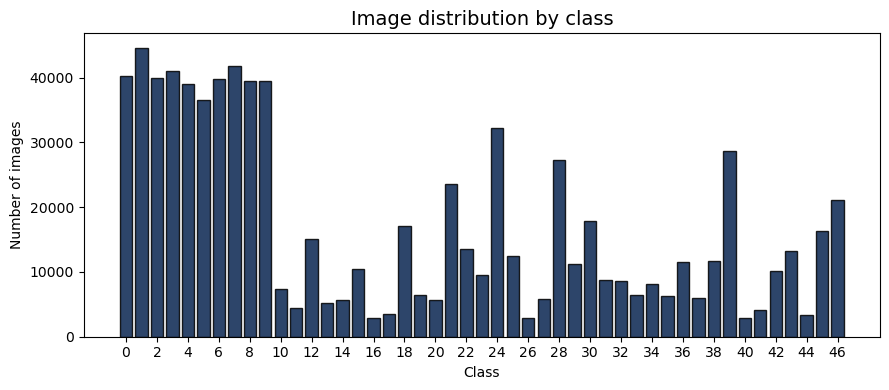

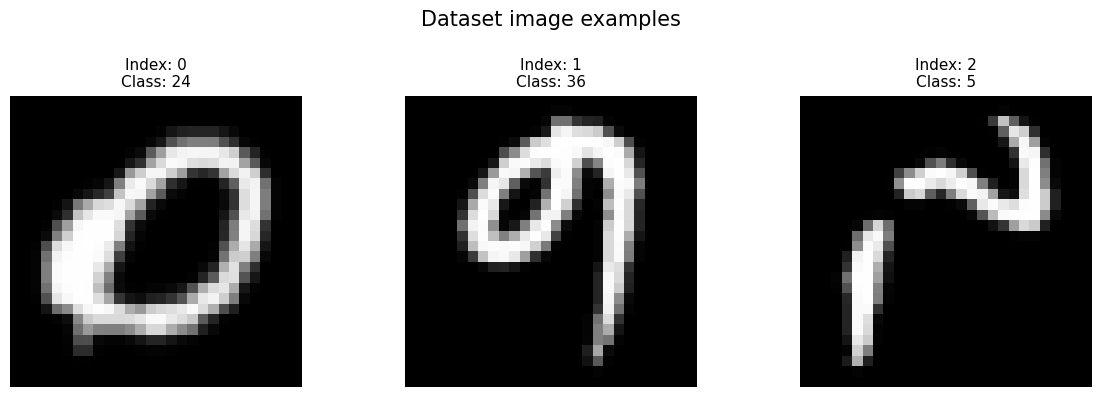

In [5]:
clases, cantidades = dataset_summary(X_img, y_img)
plot_class_distribution(clases, cantidades)

plot_images(X_img, y_img)

### b) Data Splitting

In [6]:
train, val, test = train_val_test_split(X_img, y_img)
split_summary(train, val, test)

Split summary
----------------------------------------
Train: 566667 images (70.0%)
Validation: 121410 images (15.0%)
Test: 121478 images (15.0%)

X_train shape: (566667, 28, 28)
X_val shape: (121410, 28, 28)
X_test shape: (121478, 28, 28)
y_train shape: (566667,)
y_val shape: (121410,)
y_test shape: (121478,)


### c) Normalizing

In [7]:
xtr, ytr = train
xval, yval = val
xtest, ytest = test

In [8]:
n_train = 1000
n_val = 50
n_test = 50

xtr_sample = xtr[:n_train]
xval_sample = xval[:n_val]
xtest_sample = xtest[:n_test]

ytr_sample = ytr[:n_train]
yval_sample = yval[:n_val]
ytest_sample = ytest[:n_test]

xtr_norm = normalize_image(xtr_sample).reshape(n_train, -1)
xval_norm = normalize_image(xval_sample).reshape(n_val, -1)
xtest_norm = normalize_image(xtest_sample).reshape(n_test, -1)

## 2. Basic Neural Network

### c) M0

In [9]:
M0 = MLP(input_size = 28 * 28, hidden_size = 2, hidden_nodes = [128, 64],
         output_size = xtr_norm.shape[0])

In [10]:
history_M0 = M0.fit(xtr_norm, ytr_sample, X_val = xval_norm, y_val = yval_sample,
    epochs = 200, verbose = False)

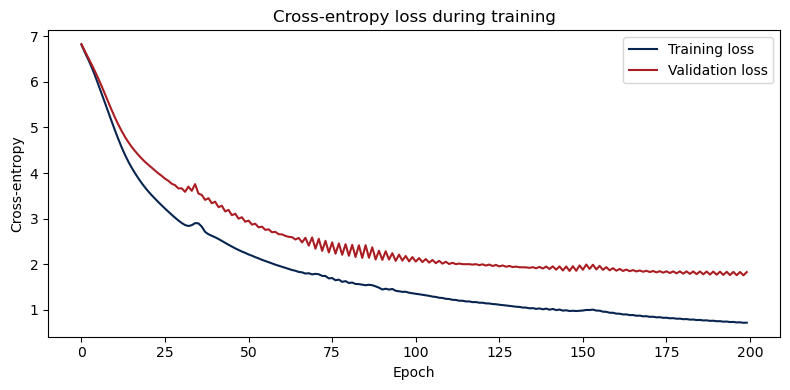

In [11]:
plot_loss_history(history_M0)

### d) Metrics

In [12]:
n_classes = len(np.unique(y_img))

train_results_M0 = evaluate_model(M0, xtr_norm, ytr_sample, n_classes)
val_results_M0 = evaluate_model(M0, xval_norm, yval_sample, n_classes)

,Train,Validation
Accuracy,0.824000,0.620000
Cross-Entropy,0.706157,1.826991
F1-Score Macro,0.755724,0.256104


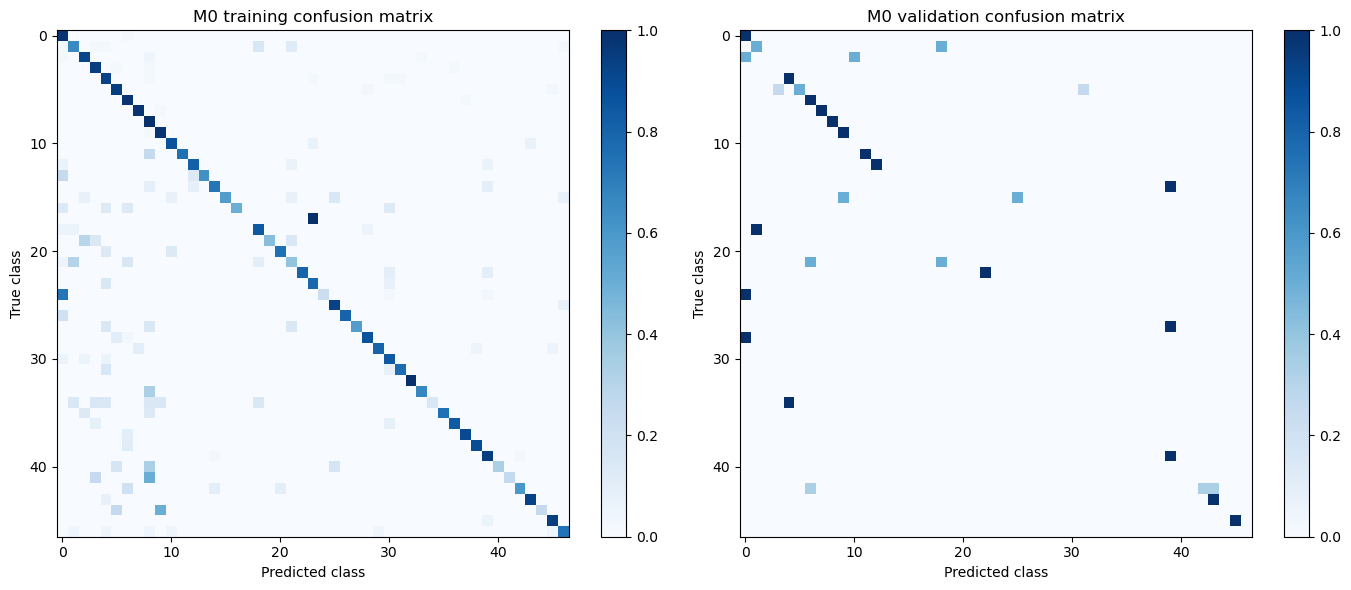

In [13]:
performance_report_table(train_results_M0, val_results_M0)

plot_confusion_matrix(
    [
        train_results_M0["confusion_matrix"],
        val_results_M0["confusion_matrix"]
    ],
    titles = [
        "M0 training confusion matrix",
        "M0 validation confusion matrix"
    ],
    normalize = True
)

## 3. Advanced Neural Network

Utilizaremos la misma confihuracion que M1, para ver como mejora en cada caso

In [14]:
model_config = {
    "input_size": 28 * 28,
    "hidden_size": 2,
    "hidden_nodes": [128, 64],
    "output_size": n_classes,
    "seed": 42
}

### a) Updated Models

In [15]:
advanced_results = {}

In [16]:
linear_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "linear",
    lr_min = 1e-4
)

advanced_results["Linear schedule"] = train_and_evaluate_model(
    linear_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = None
)

In [17]:
exponential_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "exponential",
    lr_decay = 0.95,
    lr_min = 1e-4
)

advanced_results["Exponential schedule"] = train_and_evaluate_model(
    exponential_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = None
)


In [18]:
mini_batch_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd"
)

advanced_results["Mini-batch SGD"] = train_and_evaluate_model(
    mini_batch_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = 10
)


In [19]:
adam_model = MLP(
    **model_config,
    learning_rate = 0.001,
    optimizer = "adam"
)

advanced_results["Adam"] = train_and_evaluate_model(
    adam_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = 128
)


In [20]:
l2_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    l2_lambda = 0.001
)

advanced_results["L2"] = train_and_evaluate_model(
    l2_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = 128
)


In [21]:
early_stopping_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    early_stopping = True,
    patience = 5,
    min_delta = 1e-4
)

advanced_results["Early stopping"] = train_and_evaluate_model(
    early_stopping_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 200,
    batch_size = 128
)


In [23]:
advanced_comparison_table(advanced_results)

Model,Epochs,Updates,Train Accuracy.,Val. Accuracy.,Train Cross-Entropy,Val. Cross-Entropy,Train F1,Val. F1
Linear schedule,200,200,0.24,0.22,3.24,3.34,0.08,0.07
Exponential schedule,200,200,0.05,0.04,3.78,3.82,0.01,0.01
Mini-batch SGD,200,20000,1.00,0.62,0.01,2.33,1.00,0.31
Adam,200,1600,1.00,0.70,0.00,2.53,1.00,0.36
L2,200,1600,0.81,0.60,0.73,1.60,0.69,0.26
Early stopping,200,1600,0.81,0.60,0.73,1.60,0.69,0.26
